In [2]:
#Loading required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#loading dataset from kaggle---walmart sales demand forecasting datset
data = pd.read_csv("train.csv")

data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [5]:
#the folowing steps handles missing values and converting date formats
data['Date'] = pd.to_datetime(data['Date'])

In [6]:
data = data.sort_values('Date')

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#EDA-Exploratory Data Analysis
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Weekly_Sales'])
plt.title("Retail Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

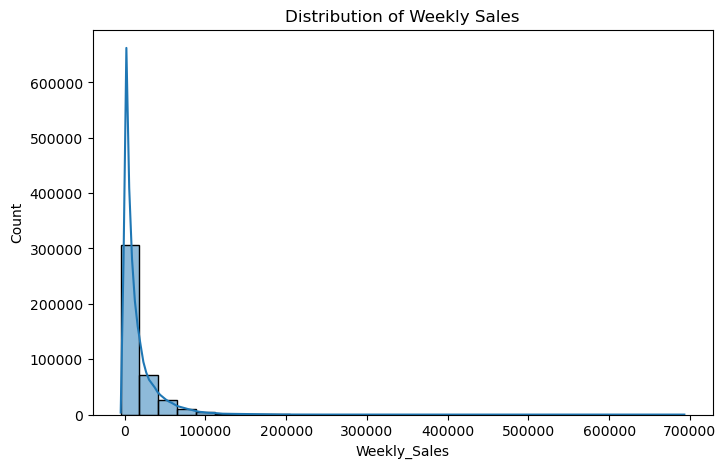

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data['Weekly_Sales'], bins=30, kde=True)
plt.title("Distribution of Weekly Sales")
plt.show()

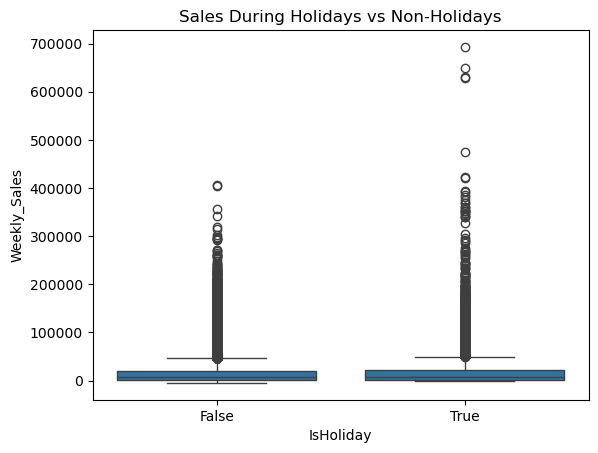

In [10]:
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=data)
plt.title("Sales During Holidays vs Non-Holidays")
plt.show()

In [11]:
data['Month'] = data['Date'].dt.month

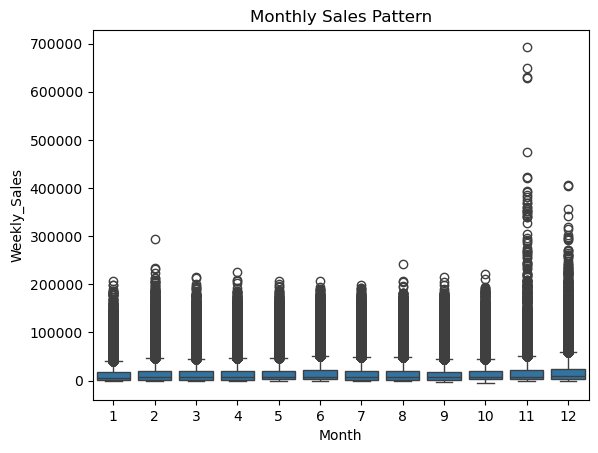

In [12]:
sns.boxplot(x='Month', y='Weekly_Sales', data=data)
plt.title("Monthly Sales Pattern")
plt.show()

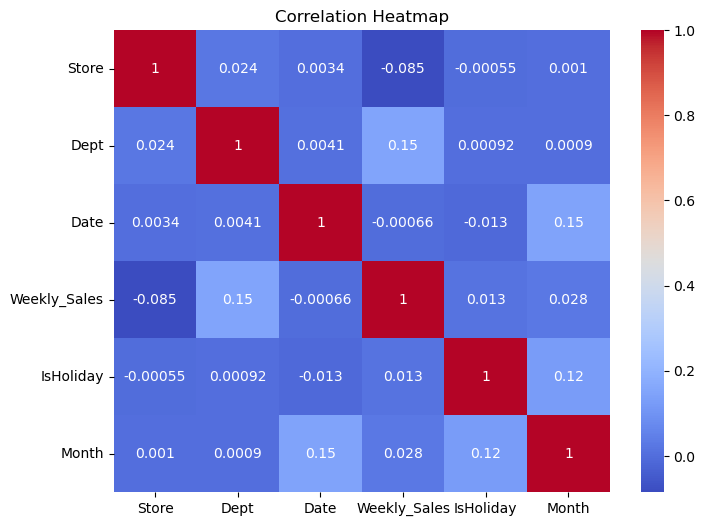

In [13]:
corr = data.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

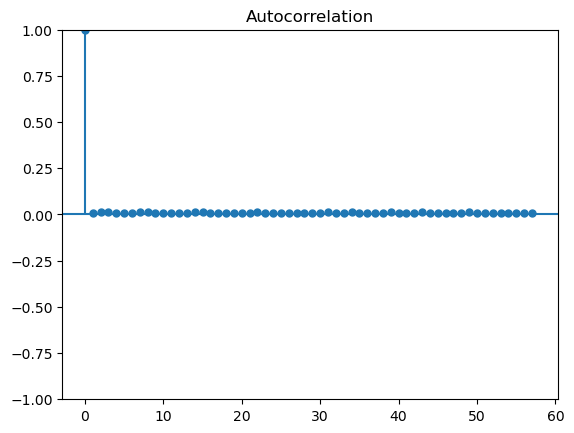

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(data['Weekly_Sales'])
plt.show()

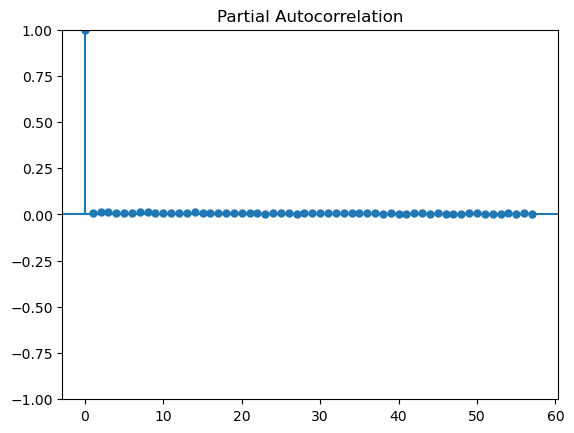

In [15]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(data['Weekly_Sales'])
plt.show()

In [16]:
#Time series analysis-stationary tests and seasonal decomposition-adf(Augmented Dickey Fuller) test
from statsmodels.tsa.stattools import adfuller

sales_series = data['Weekly_Sales'].dropna().sample(5000)

result = adfuller(sales_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -69.41360756889176
p-value: 0.0


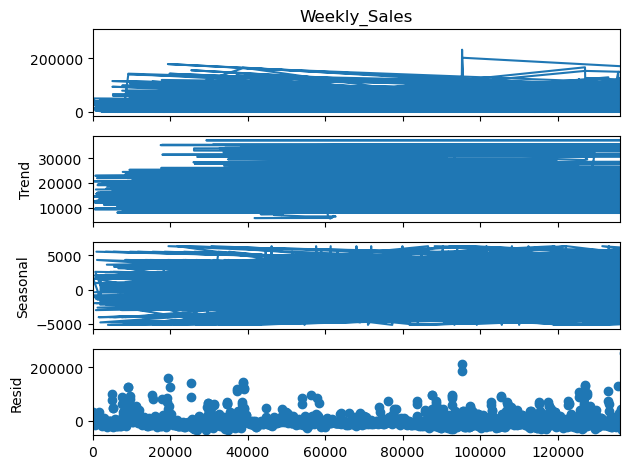

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

sales_subset = data['Weekly_Sales'].iloc[:5000]

decomposition = seasonal_decompose(sales_subset, model='additive', period=52)

decomposition.plot()

plt.show()

In [21]:
#training arima(AutoRegressive Integrated Moving Average)
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')

In [22]:
sales = data['Weekly_Sales']

split = int(len(sales) * 0.8)

train = sales[:split]
test = sales[split:]

In [23]:
#arima building
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,0,0))

result = model.fit()

print(result.summary())

C:\Users\minhaj unnisa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\minhaj unnisa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\minhaj unnisa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:               337256
Model:                 ARIMA(1, 0, 0)   Log Likelihood            -3864171.219
Date:                Sat, 28 Mar 2026   AIC                        7728348.438
Time:                        08:38:22   BIC                        7728380.624
Sample:                             0   HQIC                       7728357.701
                             - 337256                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.603e+04     39.903    401.769      0.000     1.6e+04    1.61e+04
ar.L1          0.0110      0.001      7.552      0.000       0.008       0.014
sigma2      5.243e+08      0.003   1.77e+11      0.0

In [24]:
forecast = result.predict(start=len(train), end=len(train)+len(test)-1)

C:\Users\minhaj unnisa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\minhaj unnisa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


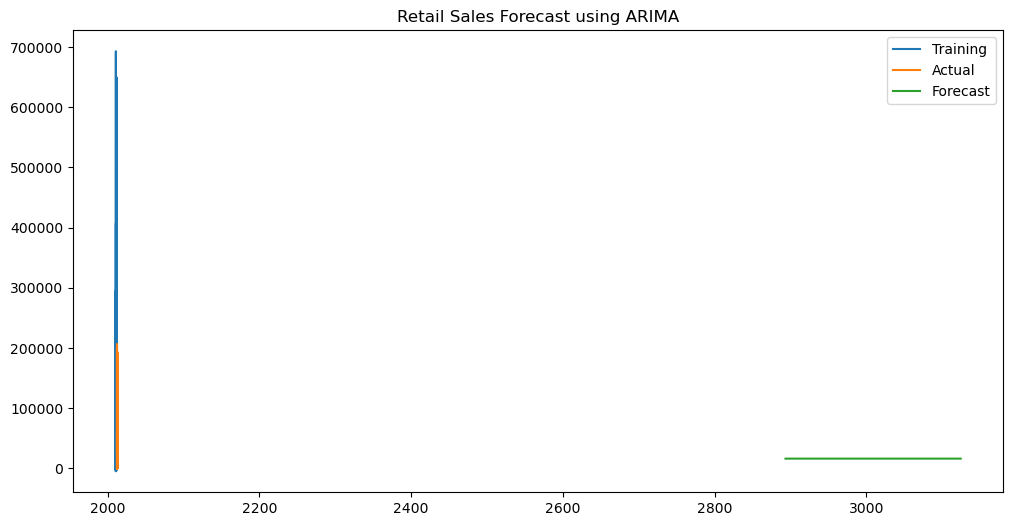

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast")

plt.legend()

plt.title("Retail Sales Forecast using ARIMA")

plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, forecast)

print("MAE:", mae)

MAE: 15098.349391431095


In [27]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [28]:
#scale data
sales = data['Weekly_Sales'].values.reshape(-1,1)

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(sales)

In [29]:
X = []
y = []

for i in range(10, len(scaled_data)):
    X.append(scaled_data[i-10:i,0])
    y.append(scaled_data[i,0])

X = np.array(X)
y = np.array(y)

In [30]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [31]:
#train test split for lstm(Long-Short Term Memory)
split = int(0.8*len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [32]:
#building lstm
model = Sequential()

model.add(LSTM(50, input_shape=(X.shape[1],1)))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\minhaj unnisa\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - loss: 0.0011
Epoch 2/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 0.0011
Epoch 3/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0011
Epoch 4/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0011
Epoch 5/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0011
Epoch 6/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0011
Epoch 7/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 0.0011
Epoch 8/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0011
Epoch 9/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0011
Epoch 10/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0011
Epoch 11/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0011
Epoch 12/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0011
Epoch 13/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0011
Epoch 14/20
10539/10539 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - 

In [34]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

2635/2635 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


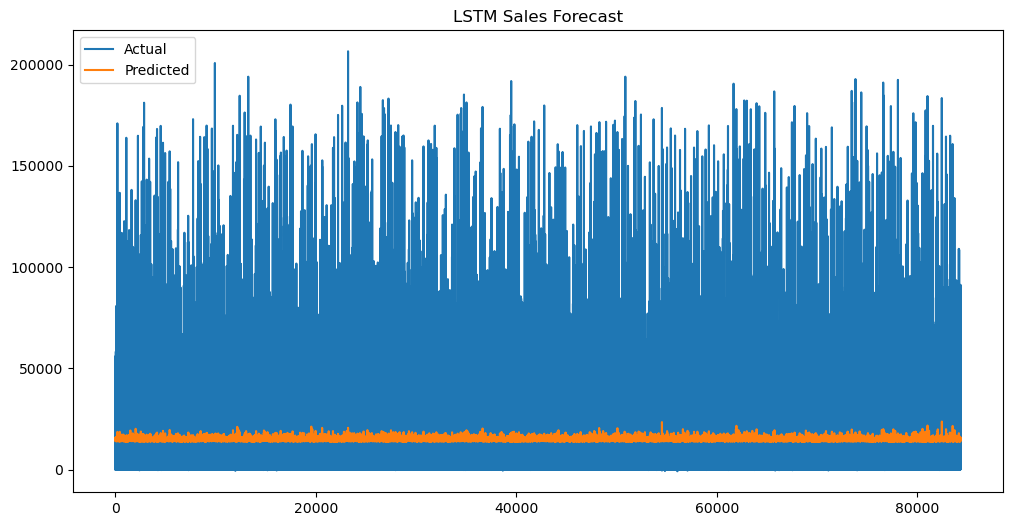

In [35]:
actual = scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()

plt.title("LSTM Sales Forecast")

plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error

mae_lstm = mean_absolute_error(actual, predictions)

print("LSTM MAE:", mae_lstm)

LSTM MAE: 14741.035237812288


In [1]:
import matplotlib.pyplot as plt

models = ['ARIMA', 'LSTM']
mae_values = [14741, mae_lstm]   # replace mae_lstm with your value

plt.figure(figsize=(8,5))
plt.bar(models, mae_values)

plt.title("Model Performance Comparison")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Forecasting Models")

plt.show()

NameError: name 'mae_lstm' is not defined

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [42]:
#ml model random forest starts here..random forest learns non-linear relationships between time-based features and sales demand
data['year'] = data.index.year
data['month'] = data.index.month
data['week'] = data.index.isocalendar().week
data['day'] = data.index.day

In [43]:
X = data[['year','month','week','day']]
y = data['Weekly_Sales']

In [46]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [45]:
#training random forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
rf_predictions=rf_model.predict(X_test)


In [50]:
#evaluating ml model---random forest
rf_mae=mean_absolute_error(y_test,rf_predictions)
print("Random Forest MAE:",rf_mae)

Random Forest MAE: 15048.36675013042


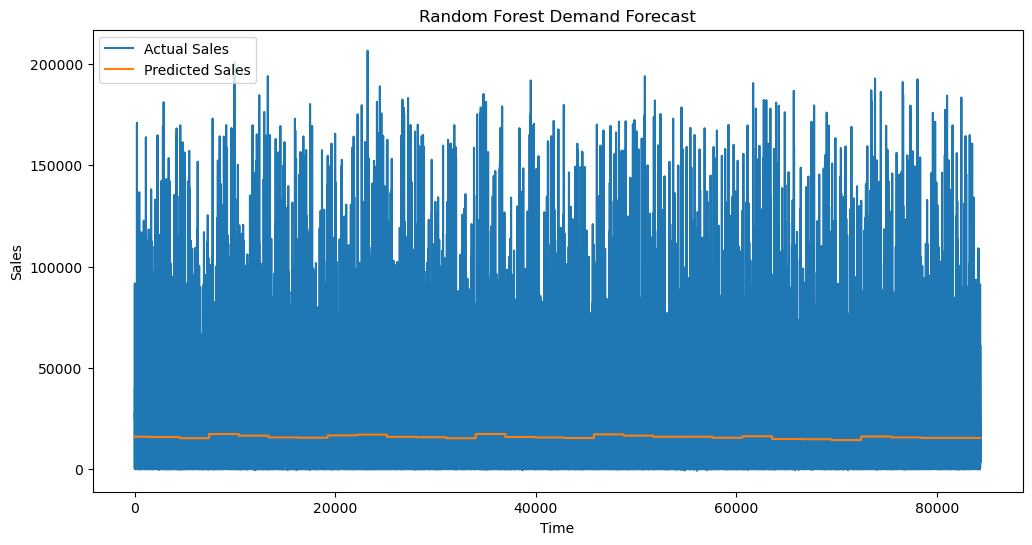

In [51]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(rf_predictions, label="Predicted Sales")

plt.title("Random Forest Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()

plt.show()

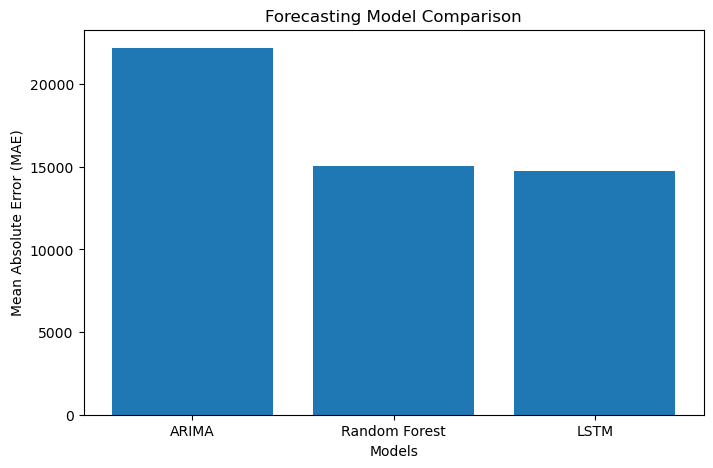

In [53]:
#comparision of three models---final conclusion:the comparitive analysis od arima,random forest and lstm models indicates that deep learning approaches aoutperform traditional statistical & machine learning techniques for retail demand forecasting due to their ability to capture complex temporal dependencies.
models = ['ARIMA','Random Forest','LSTM']
mae_values = [22180, rf_mae, mae_lstm]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(models, mae_values)

plt.title("Forecasting Model Comparison")
plt.xlabel("Models")
plt.ylabel("Mean Absolute Error (MAE)")

plt.show()